<a href="https://colab.research.google.com/github/lamaljalal/MachineLearning/blob/main/Lab9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


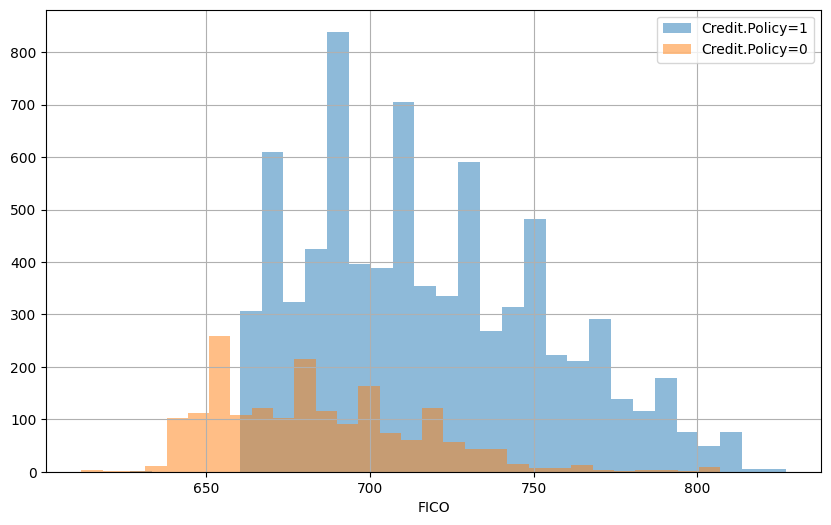

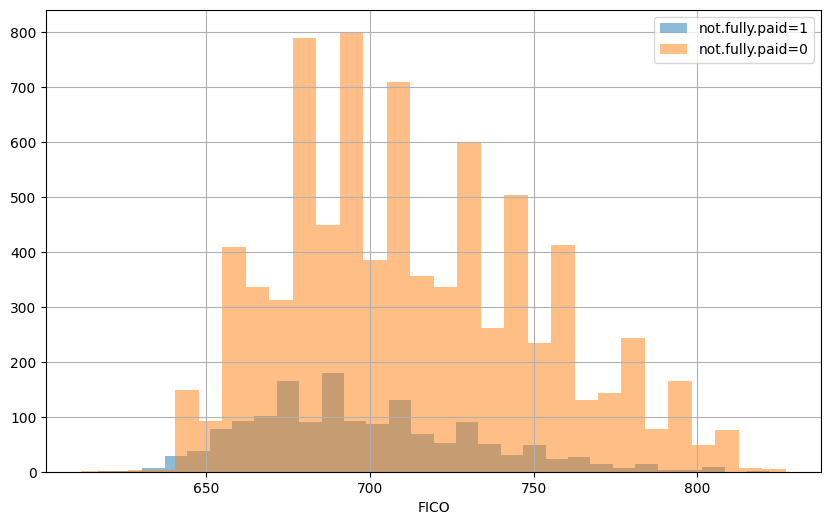

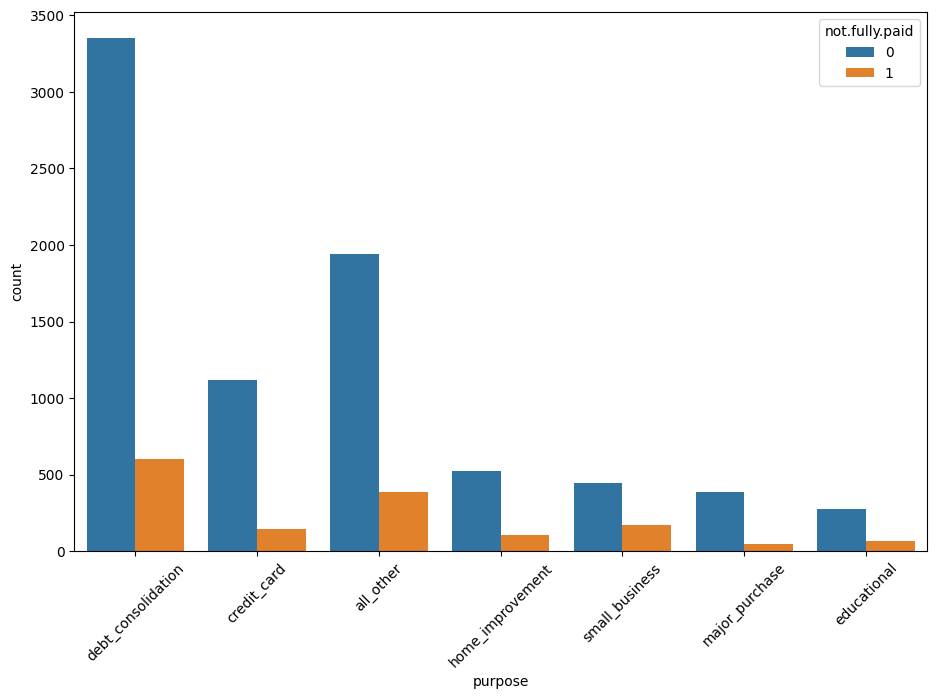

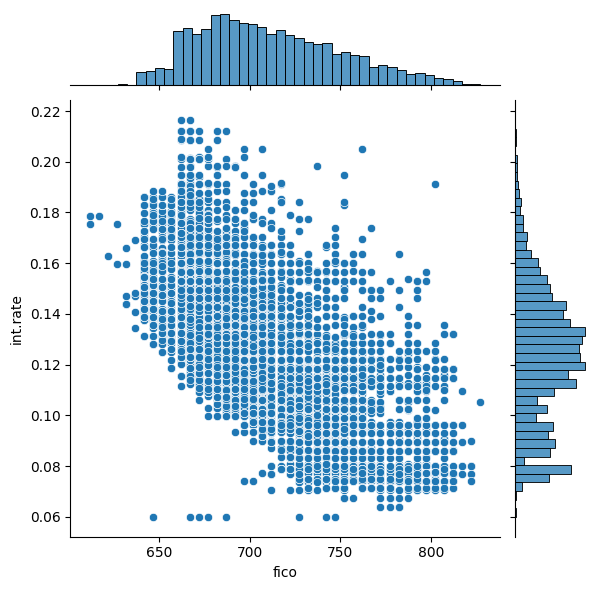

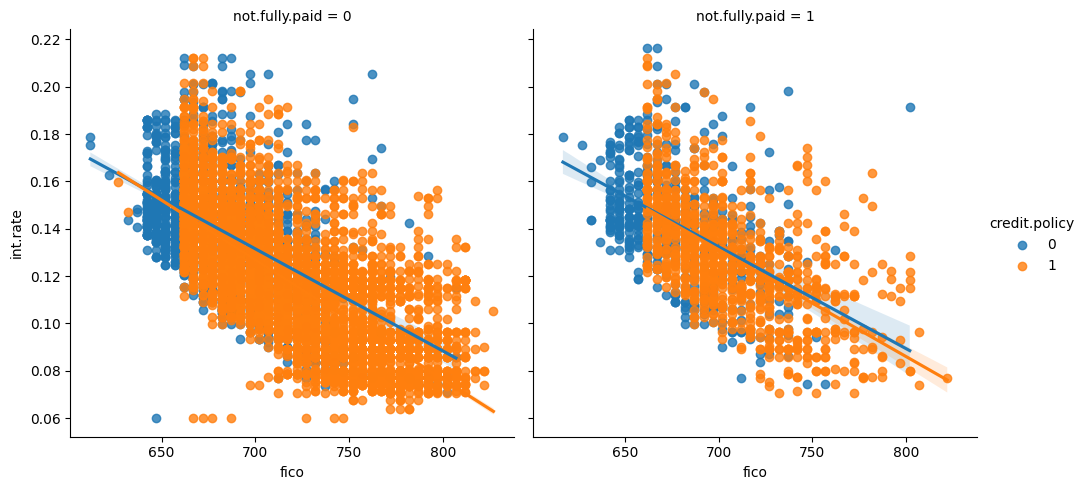

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB
              precision    recall  f1-score   support

        

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

loans = pd.read_csv("loan_data.csv")

loans.info()
loans.head()
loans.describe()

plt.figure(figsize=(10,6))
loans[loans["credit.policy"] == 1]["fico"].hist(alpha=0.5, bins=30, label="Credit.Policy=1")
loans[loans["credit.policy"] == 0]["fico"].hist(alpha=0.5, bins=30, label="Credit.Policy=0")
plt.legend()
plt.xlabel("FICO")
plt.show()

plt.figure(figsize=(10,6))
loans[loans["not.fully.paid"] == 1]["fico"].hist(alpha=0.5, bins=30, label="not.fully.paid=1")
loans[loans["not.fully.paid"] == 0]["fico"].hist(alpha=0.5, bins=30, label="not.fully.paid=0")
plt.legend()
plt.xlabel("FICO")
plt.show()

plt.figure(figsize=(11,7))
sns.countplot(x="purpose", hue="not.fully.paid", data=loans)
plt.xticks(rotation=45)
plt.show()

sns.jointplot(x="fico", y="int.rate", data=loans)
plt.show()

sns.lmplot(x="fico", y="int.rate", data=loans, hue="credit.policy", col="not.fully.paid")
plt.show()

loans.info()

cat_feats = ["purpose"]

final_data = pd.get_dummies(loans, columns=cat_feats, drop_first=True)

from sklearn.model_selection import train_test_split

X = final_data.drop("not.fully.paid", axis=1)
y = final_data["not.fully.paid"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=101
)

from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

predictions = dtree.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))

from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=600)
rfc.fit(X_train, y_train)

predictions = rfc.predict(X_test)

print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))